# Lab 9: Support Vector Machine, PCA, and LDA

## Aim

To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real-world datasets.

## Objectives

1. Train and compare SVM classifiers using different kernels.
2. Evaluate the classifiers with accuracy, precision, recall, F1 score, and confusion matrices.
3. reduce the 13-feature Wine dataset to two principal components.
4. Analyse explained variance and determine the components required for 95% variance.
5. Compare supervised SVM/LDA with unsupervised PCA.

The notebook uses the supplied WDBC and Wine data files. The final section completes the extra-credit LDA task.

In [10]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, silhouette_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Working directory:", ROOT)
print("Data files found:", (ROOT / "wdbc.data").exists() and (ROOT / "wine.data").exists())

Working directory: e:\College\MCA\Trimester 4\ML Labs\LabProgs\LAB09
Data files found: True


## Part A: Support Vector Machine

The WDBC dataset has 569 rows and 30 numerical features. The ID column is removed.

The features are standardized before applying SVM.

In [11]:
base_features = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry",
    "fractal_dimension"
]
wdbc_features = [
    f"{feature}_{statistic}"
    for statistic in ("mean", "se", "worst")
    for feature in base_features
]
wdbc_columns = ["id", "diagnosis", *wdbc_features]

wdbc = pd.read_csv(ROOT / "wdbc.data", header=None, names=wdbc_columns)
assert wdbc.shape == (569, 32)
assert not wdbc.isna().any().any()

X = wdbc[wdbc_features]
y = wdbc["diagnosis"]

print("Dataset shape:", wdbc.shape)
print("Predictive feature count:", X.shape[1])
print("\nClass distribution:")
display(y.value_counts().rename_axis("diagnosis").to_frame("count"))
display(wdbc.head())

Dataset shape: (569, 32)
Predictive feature count: 30

Class distribution:


,count
diagnosis,
B,357
M,212


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Test class counts:")
display(y_test.value_counts().rename_axis("diagnosis").to_frame("count"))

Training shape: (455, 30)
Testing shape: (114, 30)
Test class counts:


,count
diagnosis,
B,72
M,42


### Hyperparameter tuning

Linear, RBF, polynomial, and sigmoid kernels are tuned using 5-fold cross-validation.

In [13]:
parameter_grids = {
    "linear": {"svc__C": [0.01, 0.1, 1, 10, 100]},
    "rbf": {
        "svc__C": [0.1, 1, 10, 100],
        "svc__gamma": ["scale", 0.001, 0.01, 0.1],
    },
    "poly": {
        "svc__C": [0.1, 1, 10],
        "svc__gamma": ["scale", 0.01, 0.1],
        "svc__degree": [2, 3],
    },
    "sigmoid": {
        "svc__C": [0.01, 0.1, 1, 10],
        "svc__gamma": ["scale", 0.001, 0.01, 0.1],
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metric_rows = []
tuning_rows = []
confusion_matrices = {}

for kernel, grid in parameter_grids.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel=kernel)),
    ])
    search = GridSearchCV(
        pipeline,
        grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    predictions = search.predict(X_test)
    matrix = confusion_matrix(y_test, predictions, labels=["B", "M"])
    confusion_matrices[kernel] = matrix

    metric_rows.append({
        "kernel": kernel,
        "accuracy": accuracy_score(y_test, predictions),
        "precision_malignant": precision_score(y_test, predictions, pos_label="M"),
        "recall_malignant": recall_score(y_test, predictions, pos_label="M"),
        "f1_malignant": f1_score(y_test, predictions, pos_label="M"),
        "TN": int(matrix[0, 0]),
        "FP": int(matrix[0, 1]),
        "FN": int(matrix[1, 0]),
        "TP": int(matrix[1, 1]),
    })
    tuning_rows.append({
        "kernel": kernel,
        "best_cv_macro_f1": search.best_score_,
        "best_parameters": json.dumps(search.best_params_, sort_keys=True),
    })

svm_metrics = (
    pd.DataFrame(metric_rows)
    .sort_values(["f1_malignant", "accuracy"], ascending=False)
    .reset_index(drop=True)
)
svm_tuning = pd.DataFrame(tuning_rows).sort_values(
    "best_cv_macro_f1", ascending=False
).reset_index(drop=True)

print("Cross-validation tuning results:")
display(svm_tuning.style.format({"best_cv_macro_f1": "{:.4f}"}))
print("Held-out test results (malignant is the positive class):")
display(svm_metrics.style.format({
    "accuracy": "{:.4f}",
    "precision_malignant": "{:.4f}",
    "recall_malignant": "{:.4f}",
    "f1_malignant": "{:.4f}",
}))

Cross-validation tuning results:


,kernel,best_cv_macro_f1,best_parameters
0,rbf,0.9741,"{""svc__C"": 10, ""svc__gamma"": ""scale""}"
1,linear,0.9644,"{""svc__C"": 0.1}"
2,sigmoid,0.9621,"{""svc__C"": 1, ""svc__gamma"": ""scale""}"
3,poly,0.9520,"{""svc__C"": 10, ""svc__degree"": 3, ""svc__gamma"": 0.1}"


Held-out test results (malignant is the positive class):


,kernel,accuracy,precision_malignant,recall_malignant,f1_malignant,TN,FP,FN,TP
0,linear,0.9825,1.0000,0.9524,0.9756,72,0,2,40
1,rbf,0.9737,1.0000,0.9286,0.9630,72,0,3,39
2,sigmoid,0.9474,0.9737,0.8810,0.9250,71,1,5,37
3,poly,0.9386,0.9487,0.8810,0.9136,70,2,5,37


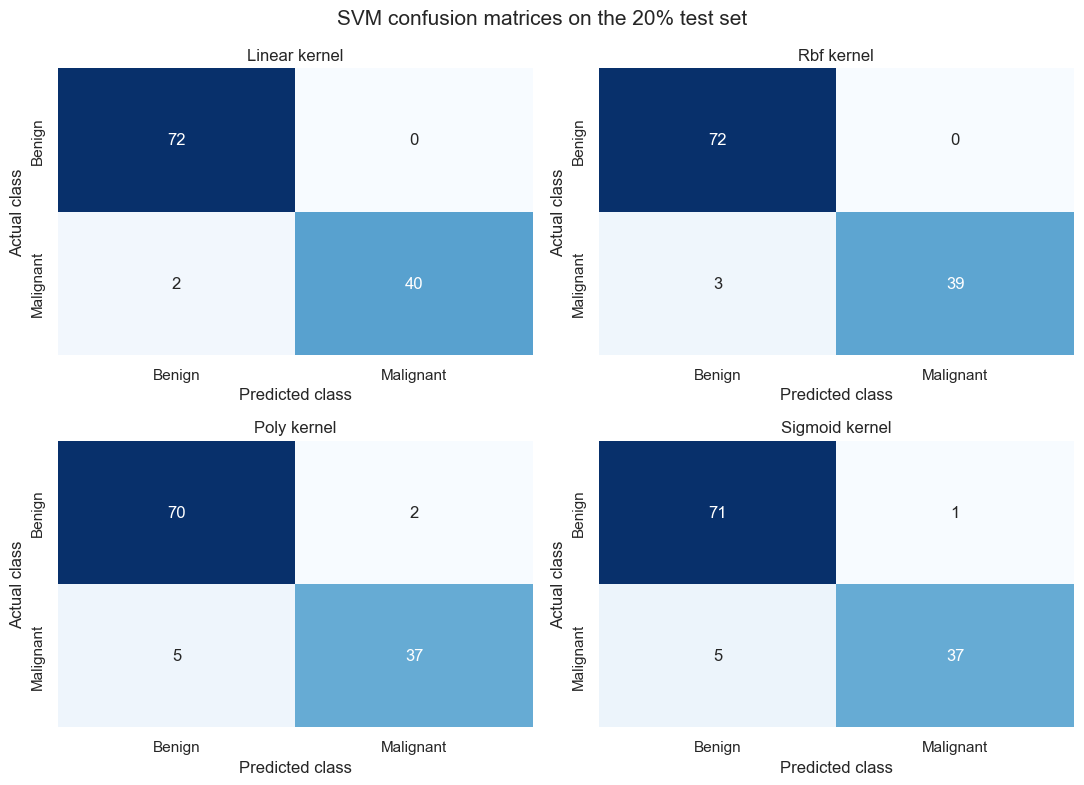

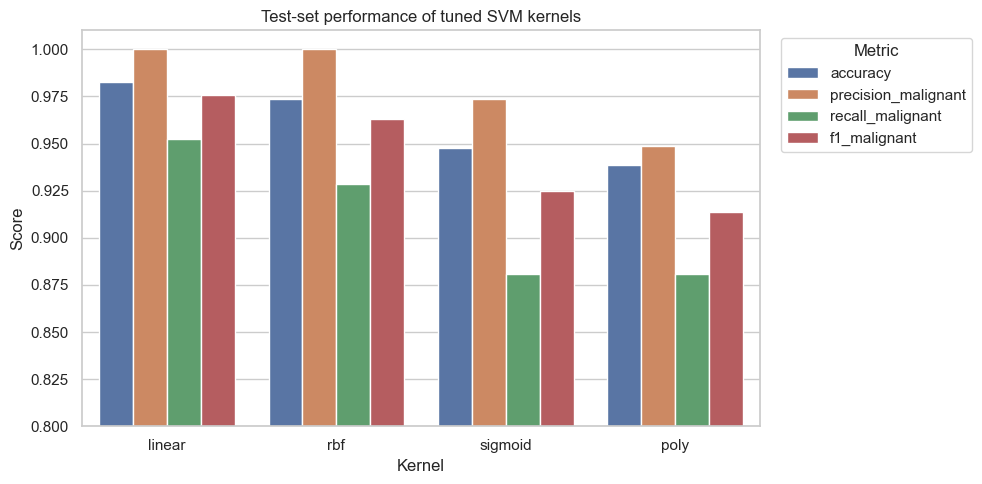

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, kernel in zip(axes.flat, parameter_grids):
    sns.heatmap(
        confusion_matrices[kernel],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"],
        ax=axis,
    )
    axis.set_title(f"{kernel.capitalize()} kernel")
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
fig.suptitle("SVM confusion matrices on the 20% test set", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "notebook_svm_confusion_matrices.png", dpi=180)
plt.show()

metric_columns = [
    "accuracy", "precision_malignant", "recall_malignant", "f1_malignant"
]
plot_data = svm_metrics.melt(
    id_vars="kernel",
    value_vars=metric_columns,
    var_name="metric",
    value_name="score",
)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x="kernel", y="score", hue="metric")
plt.ylim(0.80, 1.01)
plt.title("Test-set performance of tuned SVM kernels")
plt.xlabel("Kernel")
plt.ylabel("Score")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "notebook_svm_kernel_comparison.png", dpi=180)
plt.show()

### SVM observations

- Linear SVM gave the best test accuracy (98.25%) and F1 score (97.56%).
- It correctly identified 40 of 42 malignant cases.
- Polynomial and sigmoid kernels performed lower than linear and RBF.

## Part B: Principal Component Analysis

The Wine dataset has 178 rows, 13 features, and three classes.

The features are standardized before PCA.

In [15]:
wine_features = [
    "alcohol", "malic_acid", "ash", "alcalinity_of_ash", "magnesium",
    "total_phenols", "flavanoids", "nonflavanoid_phenols",
    "proanthocyanins", "color_intensity", "hue", "od280_od315", "proline"
]
wine = pd.read_csv(
    ROOT / "wine.data",
    header=None,
    names=["class", *wine_features],
)
assert wine.shape == (178, 14)
assert not wine.isna().any().any()

X_wine = wine[wine_features]
y_wine = wine["class"]
X_wine_scaled = StandardScaler().fit_transform(X_wine)

print("Wine dataset shape:", wine.shape)
print("Original feature count:", X_wine.shape[1])
print("Class distribution:")
display(y_wine.value_counts().sort_index().rename_axis("class").to_frame("count"))
display(wine.head())

Wine dataset shape: (178, 14)
Original feature count: 13
Class distribution:


,count
class,
1,59
2,71
3,48


,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [16]:
pca = PCA()
X_pca_all = pca.fit_transform(X_wine_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
components_for_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)
X_pca_2d = X_pca_all[:, :2]

variance_table = pd.DataFrame({
    "principal_component": np.arange(1, 14),
    "explained_variance_ratio": explained_variance,
    "cumulative_explained_variance": cumulative_variance,
})

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"First two PCs retain: {cumulative_variance[1]:.2%}")
print(
    f"Minimum PCs for at least 95% variance: {components_for_95} "
    f"({cumulative_variance[components_for_95 - 1]:.2%})"
)
display(variance_table.style.format({
    "explained_variance_ratio": "{:.4f}",
    "cumulative_explained_variance": "{:.4f}",
}))

PC1 explained variance: 36.20%
PC2 explained variance: 19.21%
First two PCs retain: 55.41%
Minimum PCs for at least 95% variance: 10 (96.17%)


,principal_component,explained_variance_ratio,cumulative_explained_variance
0,1,0.3620,0.3620
1,2,0.1921,0.5541
2,3,0.1112,0.6653
3,4,0.0707,0.7360
4,5,0.0656,0.8016
5,6,0.0494,0.8510
6,7,0.0424,0.8934
7,8,0.0268,0.9202
8,9,0.0222,0.9424
9,10,0.0193,0.9617


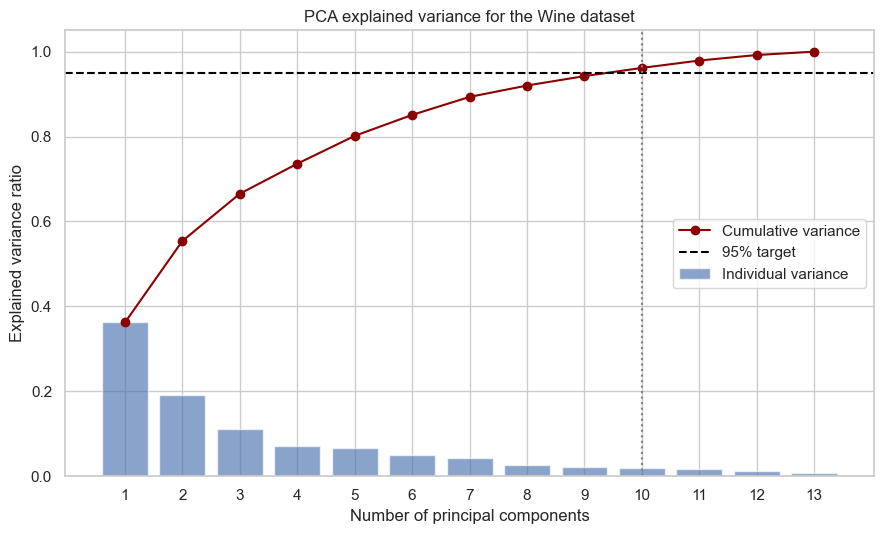

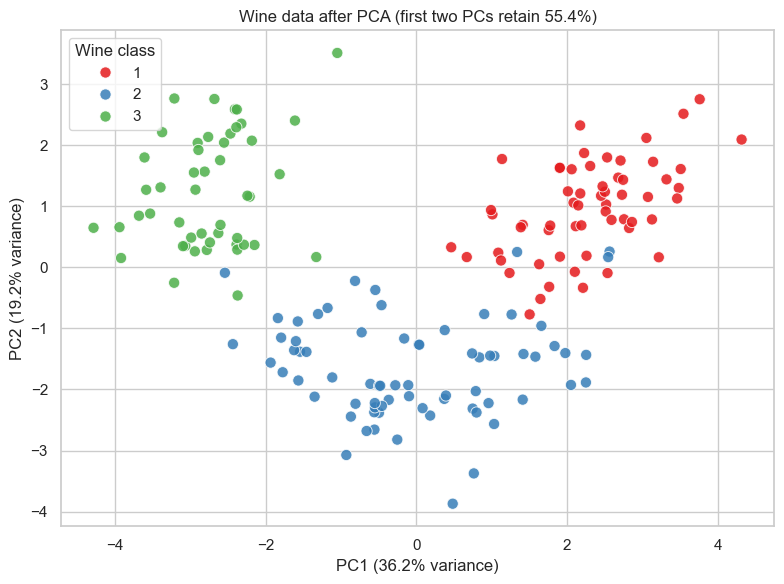

In [17]:
component_numbers = np.arange(1, 14)
fig, axis = plt.subplots(figsize=(9, 5.5))
axis.bar(component_numbers, explained_variance, alpha=0.65, label="Individual variance")
axis.plot(
    component_numbers,
    cumulative_variance,
    marker="o",
    color="darkred",
    label="Cumulative variance",
)
axis.axhline(0.95, color="black", linestyle="--", label="95% target")
axis.axvline(components_for_95, color="gray", linestyle=":")
axis.set_xticks(component_numbers)
axis.set_ylim(0, 1.05)
axis.set_xlabel("Number of principal components")
axis.set_ylabel("Explained variance ratio")
axis.set_title("PCA explained variance for the Wine dataset")
axis.legend(loc="center right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "notebook_pca_explained_variance.png", dpi=180)
plt.show()

pca_coordinates = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
pca_coordinates["class"] = y_wine.to_numpy()

fig, axis = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=pca_coordinates,
    x="PC1",
    y="PC2",
    hue="class",
    palette="Set1",
    s=65,
    alpha=0.85,
    ax=axis,
)
axis.set_title(f"Wine data after PCA (first two PCs retain {cumulative_variance[1]:.1%})")
axis.set_xlabel(f"PC1 ({explained_variance[0]:.1%} variance)")
axis.set_ylabel(f"PC2 ({explained_variance[1]:.1%} variance)")
axis.legend(title="Wine class")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "notebook_pca_wine_scatter.png", dpi=180)
plt.show()

In [18]:
loadings = pd.DataFrame({
    "feature": wine_features,
    "PC1_loading": pca.components_[0],
    "PC2_loading": pca.components_[1],
})
loadings["PC1_absolute_loading"] = loadings["PC1_loading"].abs()
loadings["PC2_absolute_loading"] = loadings["PC2_loading"].abs()

print("Largest absolute PC1 loadings:")
display(
    loadings.nlargest(5, "PC1_absolute_loading")
    [["feature", "PC1_loading", "PC1_absolute_loading"]]
    .style.format({"PC1_loading": "{:.4f}", "PC1_absolute_loading": "{:.4f}"})
)
print("Largest absolute PC2 loadings:")
display(
    loadings.nlargest(5, "PC2_absolute_loading")
    [["feature", "PC2_loading", "PC2_absolute_loading"]]
    .style.format({"PC2_loading": "{:.4f}", "PC2_absolute_loading": "{:.4f}"})
)

Largest absolute PC1 loadings:


,feature,PC1_loading,PC1_absolute_loading
6,flavanoids,0.4229,0.4229
5,total_phenols,0.3947,0.3947
11,od280_od315,0.3762,0.3762
8,proanthocyanins,0.3134,0.3134
7,nonflavanoid_phenols,-0.2985,0.2985


Largest absolute PC2 loadings:


,feature,PC2_loading,PC2_absolute_loading
9,color_intensity,0.5300,0.5300
0,alcohol,0.4837,0.4837
12,proline,0.3649,0.3649
2,ash,0.3161,0.3161
4,magnesium,0.2996,0.2996


### PCA interpretation and comparison

| Representation | Features | Information retained | Computational effect |
|---|---:|---:|---|
| Standardized original | 13 | 100% | Baseline |
| PCA visualization | 2 | 55.41% | Faster, with information loss |
| PCA at the 95% target | 10 | 96.17% | Small reduction with little loss |

PC1 mainly represents phenolic features. PC2 is influenced by color intensity, alcohol, and proline.

PCA reduces computation and helps visualization, but its components are harder to interpret and it cannot capture nonlinear patterns.

## Extra credit: Linear Discriminant Analysis

LDA uses class labels to improve separation. With three classes, it produces at most two axes.

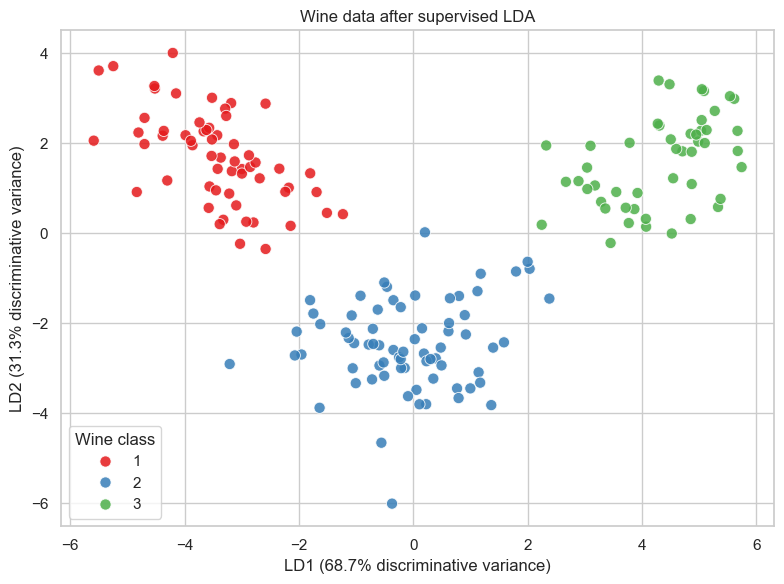

,method,dimensions,uses_class_labels,silhouette_score,between_within_scatter_ratio
0,PCA,2,False,0.5262,3.4055
1,LDA,2,True,0.6632,6.6051


In [19]:
def class_separation_ratio(values, labels):
    overall_mean = values.mean(axis=0)
    between, within = 0.0, 0.0
    label_array = np.asarray(labels)
    for label in np.unique(label_array):
        group = values[label_array == label]
        group_mean = group.mean(axis=0)
        between += len(group) * np.sum((group_mean - overall_mean) ** 2)
        within += np.sum((group - group_mean) ** 2)
    return float(between / within)

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda_2d = lda.fit_transform(X_wine_scaled, y_wine)
lda_coordinates = pd.DataFrame(X_lda_2d, columns=["LD1", "LD2"])
lda_coordinates["class"] = y_wine.to_numpy()

fig, axis = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=lda_coordinates,
    x="LD1",
    y="LD2",
    hue="class",
    palette="Set1",
    s=65,
    alpha=0.85,
    ax=axis,
)
axis.set_title("Wine data after supervised LDA")
axis.set_xlabel(f"LD1 ({lda.explained_variance_ratio_[0]:.1%} discriminative variance)")
axis.set_ylabel(f"LD2 ({lda.explained_variance_ratio_[1]:.1%} discriminative variance)")
axis.legend(title="Wine class")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "notebook_lda_wine_scatter.png", dpi=180)
plt.show()

comparison = pd.DataFrame({
    "method": ["PCA", "LDA"],
    "dimensions": [2, 2],
    "uses_class_labels": [False, True],
    "silhouette_score": [
        silhouette_score(X_pca_2d, y_wine),
        silhouette_score(X_lda_2d, y_wine),
    ],
    "between_within_scatter_ratio": [
        class_separation_ratio(X_pca_2d, y_wine),
        class_separation_ratio(X_lda_2d, y_wine),
    ],
})
display(comparison.style.format({
    "silhouette_score": "{:.4f}",
    "between_within_scatter_ratio": "{:.4f}",
}))

## Conclusion

Linear SVM achieved 98.25% accuracy. PCA reduced the Wine data to two dimensions while retaining 55.41% variance, and 10 components were needed for 95%. LDA showed clearer class separation than PCA.